In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from sklearn.preprocessing import MinMaxScaler

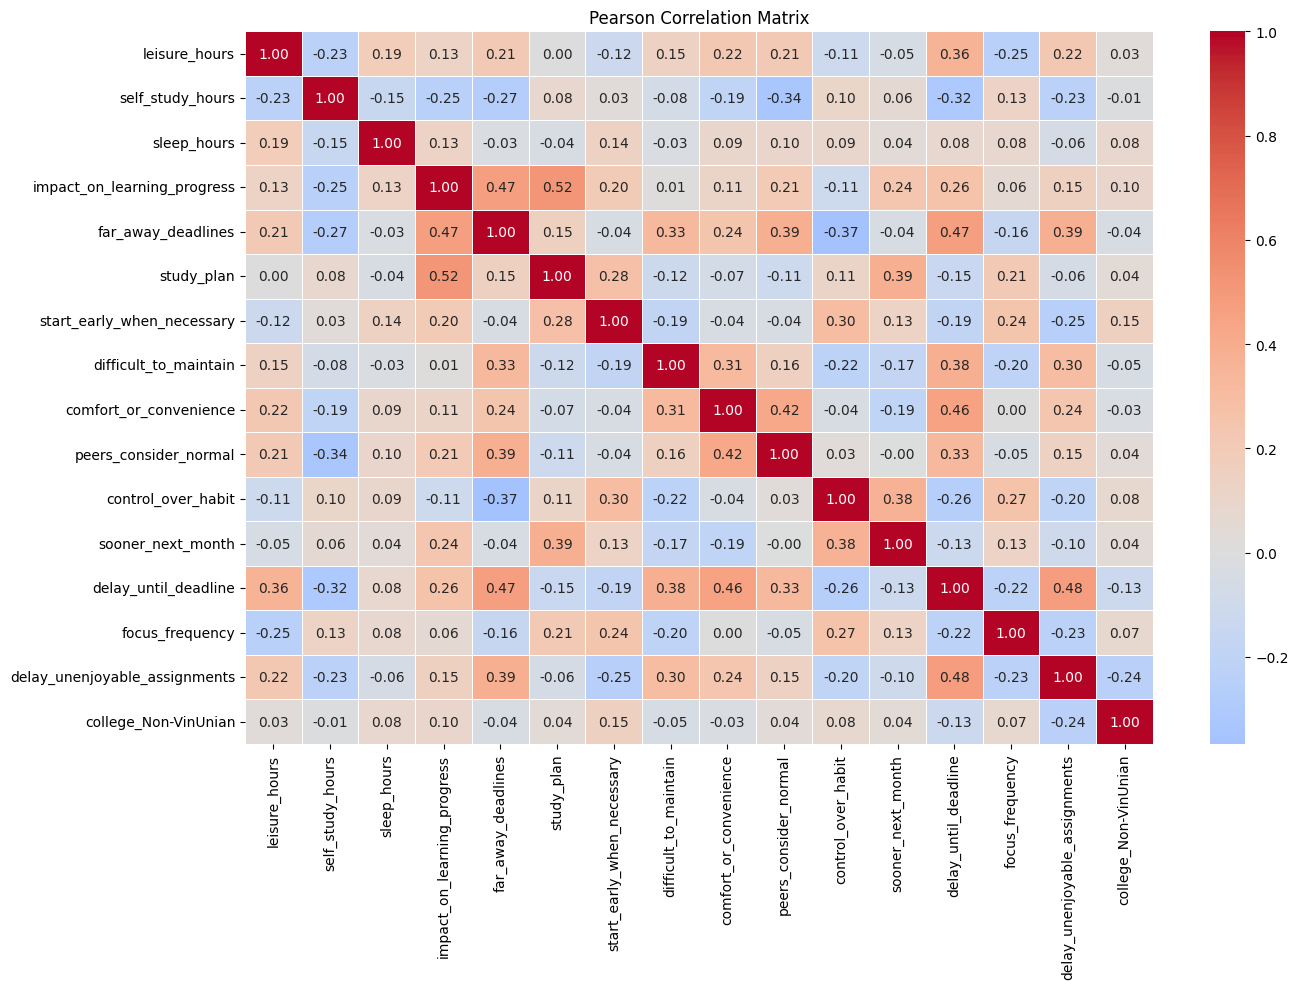

In [6]:
cleaned_df = pd.read_csv("../encoded_dataset.csv")
exclude = ['timestamp', 'age', 'gender_Male', 'gender_Female', 'gender_Prefer not to say', 'gender_Other',
            'college_CECS (Engineering & Computer Science)', 'college_CBM (Business and Management)',
            'college_CHS (Health Science)', 'college_CAS (Arts and Sciences)',
            'study_environment_Open Space', 'study_environment_Private Space', 
            'study_environment_Collab Space', 'study_environment_Flexible/Multiple',
            'year_of_study', 
            'gpa_range', 'currently_employed', 'data_quality_check', 'referrer']
df_numeric = cleaned_df.drop(columns=exclude)
corr_matrix = df_numeric.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # show r values inside cells
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # red = positive, blue = negative
    center=0,          # center color at 0
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load Data
cleaned_df = pd.read_csv("../encoded_dataset.csv")

# 2. Define the Feature Combinations we want to test
models_to_test = {
    "1. The Hybrid 5 (Chosen Model)": [
        "delay_unenjoyable_assignments", "self_study_hours", "sleep_hours", "control_over_habit", "focus_frequency"
    ],
    "2. The Original 5": [
        "leisure_hours", "self_study_hours", "sleep_hours", "control_over_habit", "focus_frequency"
    ],
    "3. Top 5 Significant (Stats Driven)": [
        "delay_unenjoyable_assignments", "comfort_or_convenience", "far_away_deadlines", "self_study_hours", "control_over_habit"
    ],
    "4. Time Metrics Only": [
        "leisure_hours", "self_study_hours", "sleep_hours"
    ],
    "5. Psychology Only": [
        "delay_unenjoyable_assignments", "focus_frequency", "control_over_habit", "comfort_or_convenience"
    ]
}

# 3. Run the Tests
results = []
K = 3 # We are keeping clusters at 3 for a fair fight

for model_name, feature_list in models_to_test.items():
    # Double check that the columns exist in the dataframe to prevent errors
    available_features = [f for f in feature_list if f in cleaned_df.columns]
    
    # Extract and drop any missing data
    X = cleaned_df[available_features].dropna()
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run K-Means
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Calculate Metrics
    sil_score = silhouette_score(X_scaled, clusters)
    inertia = kmeans.inertia_
    
    # Save Results
    results.append({
        "Model": model_name,
        "Feature Count": len(available_features),
        "Silhouette Score": round(sil_score, 4),
        "Inertia": round(inertia, 2)
    })

# 4. Display the Final Table
comparison_df = pd.DataFrame(results)
print("\n=== FEATURE COMBINATION TEST RESULTS (K=3) ===")
print(comparison_df.to_string(index=False))


=== FEATURE COMBINATION TEST RESULTS (K=3) ===
                              Model  Feature Count  Silhouette Score  Inertia
     1. The Hybrid 5 (Chosen Model)              5            0.1980   643.54
                  2. The Original 5              5            0.2095   632.22
3. Top 5 Significant (Stats Driven)              5            0.1822   626.76
               4. Time Metrics Only              3            0.2745   313.20
                 5. Psychology Only              4            0.2169   490.19


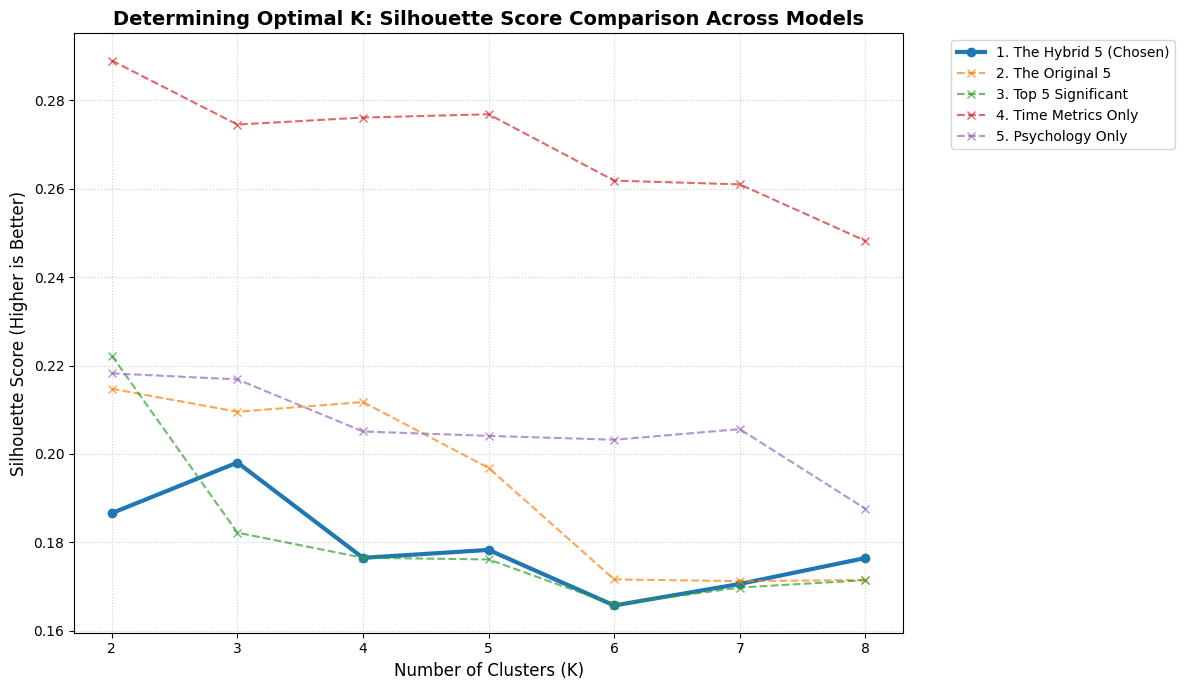

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load Data
cleaned_df = pd.read_csv("../encoded_dataset.csv")

# 2. Define the Models
models_to_test = {
    "1. The Hybrid 5 (Chosen)": ["delay_unenjoyable_assignments", "self_study_hours", "sleep_hours", "control_over_habit", "focus_frequency"],
    "2. The Original 5": ["leisure_hours", "self_study_hours", "sleep_hours", "control_over_habit", "focus_frequency"],
    "3. Top 5 Significant": ["delay_unenjoyable_assignments", "comfort_or_convenience", "far_away_deadlines", "self_study_hours", "control_over_habit"],
    "4. Time Metrics Only": ["leisure_hours", "self_study_hours", "sleep_hours"],
    "5. Psychology Only": ["delay_unenjoyable_assignments", "focus_frequency", "control_over_habit", "comfort_or_convenience"]
}

# 3. Setup the Test Range (K=2 through 8)
k_values = range(2, 9)

# 4. Prepare the Plot
plt.figure(figsize=(12, 7))

# 5. Run the Tests and Plot
for model_name, feature_list in models_to_test.items():
    available_features = [f for f in feature_list if f in cleaned_df.columns]
    X = cleaned_df[available_features].dropna()
    X_scaled = StandardScaler().fit_transform(X)
    
    scores = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)
        scores.append(silhouette_score(X_scaled, clusters))
        
    # Plot the line for this specific model
    # Making our Chosen Model a thicker, bolder line so it stands out
    if "Chosen" in model_name:
        plt.plot(k_values, scores, marker='o', linewidth=3, label=model_name)
    else:
        plt.plot(k_values, scores, marker='x', linestyle='--', alpha=0.7, label=model_name)

# 6. Format the Chart
plt.title('Determining Optimal K: Silhouette Score Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score (Higher is Better)', fontsize=12)
plt.xticks(k_values)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

K=2 Score: 0.1866
K=3 Score: 0.1980
K=4 Score: 0.1765
K=5 Score: 0.1783
K=6 Score: 0.1657
K=7 Score: 0.1706
K=8 Score: 0.1764


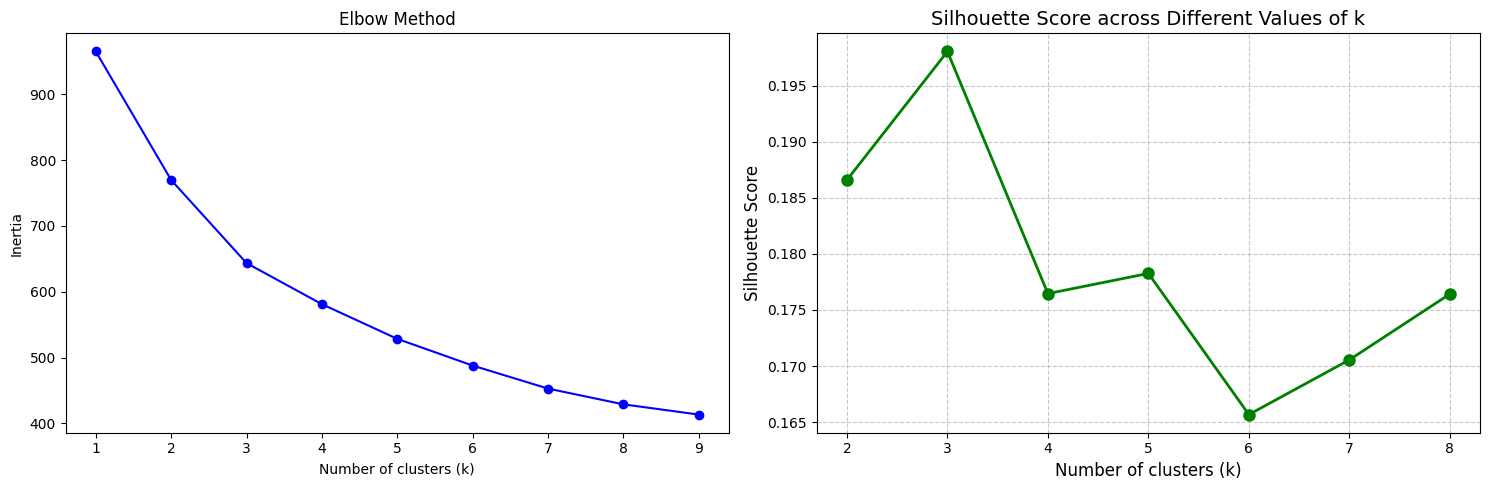

In [9]:
encoded_df = pd.read_csv("../encoded_dataset.csv")

# features: leisure_hours, self_study_hours, sleep_hours, control_over_habit, focus_frequency
# exclude: delay_until_deadline (binary), timestamp, referrer, data_quality_check


np.random.seed(42)
features = encoded_df[
    [
        "delay_unenjoyable_assignments",
        "self_study_hours",
        "sleep_hours",
        "control_over_habit",
        "focus_frequency",
    ]
]

#  Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

#  Elbow graph to find optimal K
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, preds)
    sil_scores.append(score)
    print(f"K={k} Score: {score:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot the Elbow Method graph
axes[0].plot(K, inertia, "bo-")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")


# 6. Plot the Silhouette Score Graph
axes[1].plot(K_range, sil_scores, "go-", linewidth=2, markersize=8)
axes[1].set_xlabel("Number of clusters (k)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Score across Different Values of k", fontsize=14)
axes[1].grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

K=2 Score: 0.1866
K=3 Score: 0.1980
K=4 Score: 0.1765
K=5 Score: 0.1783
K=6 Score: 0.1657
K=7 Score: 0.1706
K=8 Score: 0.1764


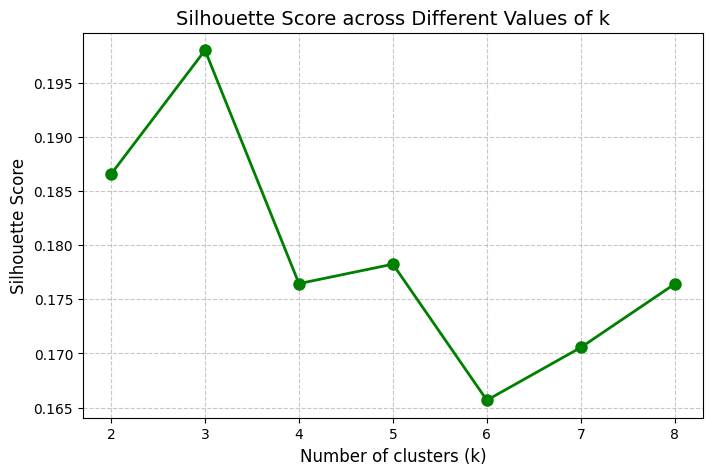

In [10]:
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, preds)
    sil_scores.append(score)
    print(f"K={k} Score: {score:.4f}")

# 6. Plot the Silhouette Score Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, "go-", linewidth=2, markersize=8)
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score across Different Values of k", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Cluster
0    73
2    70
1    50
Name: count, dtype: int64


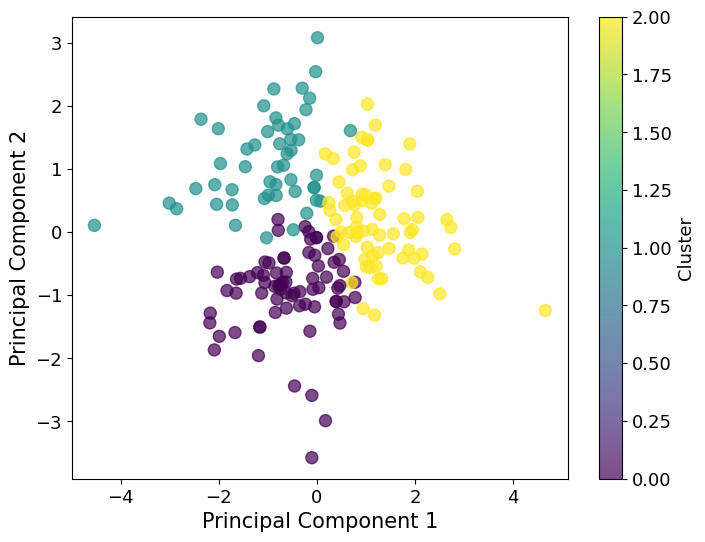

PCA Explained Variance: [0.31821889 0.23066002]


In [21]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster assignments back to the original dataset (FIXED VARIABLE NAME)
encoded_df["Cluster"] = clusters

print(encoded_df["Cluster"].value_counts())

# PCA for 2D Visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.7,
    s = 75
)
cbar = plt.colorbar(scatter)
cbar.ax.tick_params(labelsize = 13)
cbar.set_label("Cluster", fontsize = 13)
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
# plt.title("K-Means Clustering (PCA Projection)")
plt.show()

print("PCA Explained Variance:", pca.explained_variance_ratio_)

PCA Loadings
                                    PC1       PC2
delay_unenjoyable_assignments  0.541895  0.087926
self_study_hours              -0.386790 -0.591072
sleep_hours                   -0.107663  0.755755
control_over_habit            -0.506993  0.214239
focus_frequency               -0.536759  0.160747


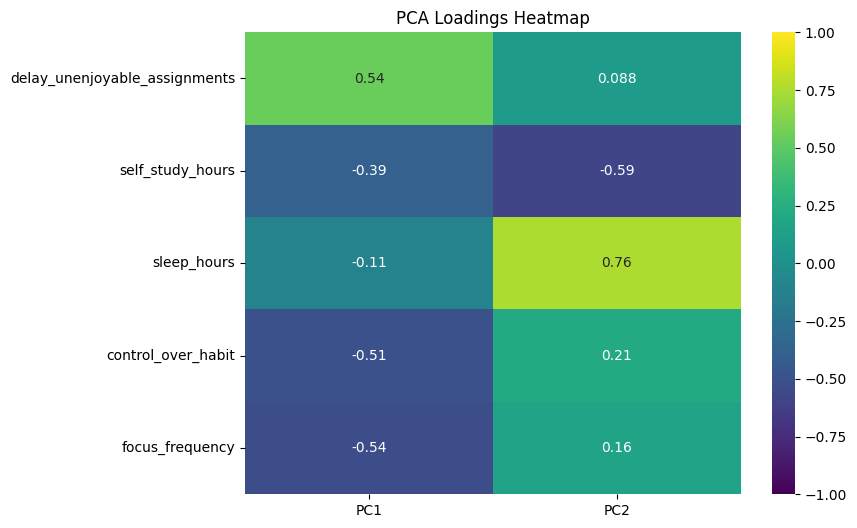

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features.columns,  # Uses the 5 features selected earlier
)

print("PCA Loadings")
print(loadings)

# 2. Plot a Heatmap for easy visual interpretation
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="viridis", center=0, vmin=-1, vmax=1)
plt.title("PCA Loadings Heatmap")
plt.show()

C:\Users\tamhu\AppData\Local\Temp\ipykernel_17916\3591159177.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  likert_legend = fig.legend(


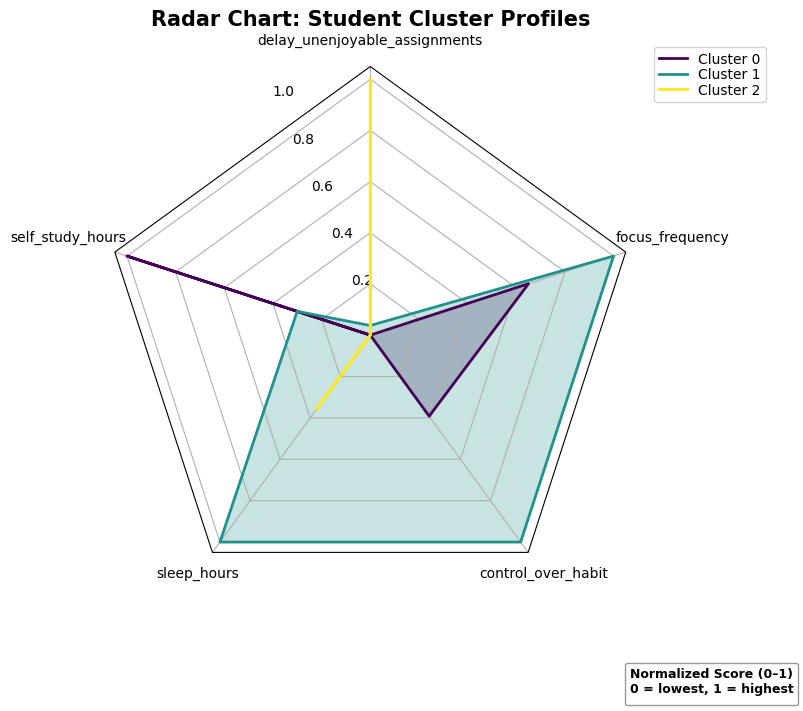

In [13]:
def radar_factory(num_vars, frame="circle"):
    """
    Create a radar chart with `num_vars` Axes.
    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = "radar"
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location("N")

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels, pads=None):
            angles_deg = np.degrees(theta)
            self.set_thetagrids(angles_deg, labels)
            if pads is not None:
                for tick, pad in zip(self.xaxis.get_major_ticks(), pads):
                    tick.set_pad(pad)

        def _gen_axes_patch(self):
            if frame == "circle":
                return Circle((0.5, 0.5), 0.5)
            elif frame == "polygon":
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == "circle":
                return super()._gen_axes_spines()
            elif frame == "polygon":
                spine = Spine(
                    axes=self,
                    spine_type="circle",
                    path=Path.unit_regular_polygon(num_vars),
                )
                spine.set_transform(
                    Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes
                )
                return {"polar": spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


df_scaled_df = pd.DataFrame(df_scaled, columns = features.columns)
df_scaled_df["Cluster"] = kmeans.labels_
cluster_means = df_scaled_df.groupby("Cluster").mean()
# encoded_df["Cluster"] = kmeans.fit_predict(df_scaled)
# cluster_means = encoded_df.groupby("Cluster")[features.columns].mean()
# Prepare categories variables
radar_scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    radar_scaler.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)
categories = cluster_means.columns.tolist()
N = len(categories)

theta = radar_factory(N, frame="polygon")

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="radar"))

# Define colors for clusters
# Define colors for clusters
colors = ["#440154", "#21918c", "#fde725"]
labels = []
handles = []

for i, row in cluster_means_scaled.iterrows():
    values = row.values
    color = colors[i]

    line, = ax.plot(theta, values, color=color, linewidth=2)
    handles.append(line)
    
    # Fill polygon
    ax.fill(theta, values, facecolor=color, alpha=0.25)

    labels.append(f"Cluster {i}")

ax.set_varlabels(categories)
default_padding = 8
extra_padding = 25

padding = []
for cat in categories:
    if cat in ("self_study_hours", "focus_frequency"):
        padding.append(extra_padding)
    else:
        padding.append(default_padding)

ax.set_varlabels(categories, pads=padding)

ax.set_title(
    "Radar Chart: Student Cluster Profiles", weight="bold", size=15, position=(0.5, 1.1)
)


# Update ax.legend to include handles
ax.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.25, 1.05),
    labelspacing=0.1,
    fontsize="medium",
)
likert_legend = fig.legend(
    # handles=likert_handles,
    title="Normalized Score (0–1)\n0 = lowest, 1 = highest",
    title_fontsize=9,
    loc="lower right",
    fontsize=8,
    edgecolor="grey",
    handlelength=0,
    handleheight=0,
)
likert_legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()